In [7]:
import numpy as np
import os
import matplotlib.pyplot as plt

In [8]:
plt.style.use('default')
directorio = "data_sin_SRH"

for archivo in os.listdir(directorio):
    if archivo.endswith(".npy"):
        nombre = os.path.splitext(archivo)[0]
        ruta = os.path.join(directorio, archivo)

        globals()[nombre] = np.load(ruta)

In [9]:
xp_etd = -0.2196e-4 + 9e-4
xn_etd = 0.4392e-4 + 9e-4
xp_Va_max = -0.1396e-4 + 9e-4
xn_Va_max = 0.2792e-4 + 9e-4
idx_xp_etd = np.argmin(np.abs(x_vector_Efield - xp_etd))
idx_xn_etd = np.argmin(np.abs(x_vector_Efield - xn_etd))
idx_xp_Va_max = np.argmin(np.abs(x_vector_Efield - xp_Va_max))
idx_xn_Va_max = np.argmin(np.abs(x_vector_Efield - xn_Va_max))

# PUNTO 11

11. DEVSIM Active el par ́ametro enable SRH, que incorpora el modelo de Shockley-Reed-Hall a la
simulaci ́on. Vuelva a graficar la densidad de corriente con el modelo del diodo ideal superpuesta
con la curva de corriente generada por DEVSIM barriendo entre las dos tensiones indicadas en
la consigna. Utilizar una figura.
¿Cu ́anto difieren las curvas entre s ́ı? ¿Es la diferencia despreciable? ¿Las curvas difieren
m ́as que en el  ́ıtem 6?
Siendo que la consecuencia de habilitar enable SRH es que la simulaci ́on contemple el
efecto de Shockley-Reed-Hall, ¿c ́omo explicar ́ıa esto la diferencia entre las curvas (si es
que la diferencia existe en su caso)?

In [10]:
q = 1.602e-19
D_n = 35 #Cm²/s
mu_n = 1350 #Cm²/Vs
q = 1.602e-19
D_p = 12.4 #Cm²/s
mu_p = 480 #Cm²/Vs

Na = 6e15 # [cm-3] Dopaje aceptor lado P
Nd = 3e15 # [cm-3] Dopaje donor lado N
Wp = 9e-4 # [cm] Extension lado P (incluyendo QNR-P y zona de vaciamiento P)
Wn = 7e-4 # [cm] Extension lado N (incluyendo QNR-N y zona de vaciamiento N)
taup = 37e-6 # Tiempo de vida de los minoritarios
taun = 37e-6 # Tiempo de vida de los minoritarios
Va_min = -0.3 # [V] Minima tension en reversa
Va_max = 0.4 # [V] Maxima tension en directa
altura = 10e-4 # [cm] Altura del diodo. A mayor altura, mayor corriente

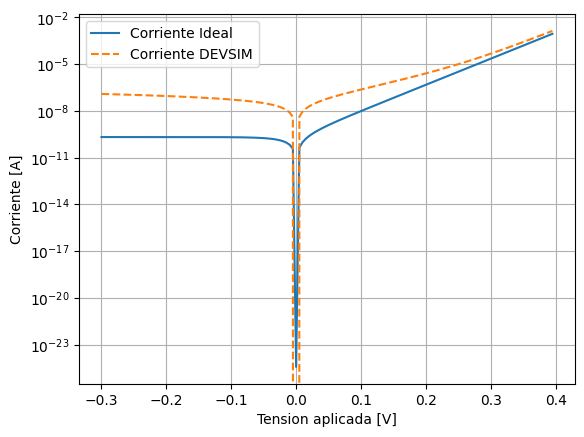

In [12]:
ni = 1e10  # Concentración intrínseca [cm^-3 o m^-3]

xp = 0.2196e-4  # Extensión de la zona de agotamiento hacia p
xn = 0.4392e-4  # Extensión de la zona de agotamiento hacia n

Vth = 25.9e-3  # Tensión térmica [V]
Js = q * ni ** 2 * (
        D_n / ((Wp - xp) * Na)
        + D_p / ((Wn - xn) * Nd)
)
Va = np.linspace(Va_min, Va_max, 1000)

J_ideal = Js * (np.exp(np.array(voltage) / Vth) - 1)

plt.figure()
plt.plot(voltage, np.abs(J_ideal), label='Corriente Ideal')
plt.plot(voltage, np.abs(np.array(total_current_srh) / np.array(altura)), label='Corriente DEVSIM',
         linestyle='dashed')
plt.semilogy()
plt.legend()
plt.ylabel('Corriente [A]')
plt.xlabel(r"Tension aplicada [V]")
plt.grid()
plt.savefig("res/fig_11_corriente.pdf")
plt.show()